In [1]:
from elucidated_diffusion.elucidated_diffusion import edm_ancestral_sampling_for_diffusion
from elucidated_diffusion.elucidated_diffusion import edm_ancestral_sampling_for_sr
from elucidated_diffusion.elucidated_diffusion import P_mean, P_std, sigma_data, edm_loss_weight
from elucidated_diffusion.ema_helper import EMAHelper
from elucidated_diffusion.models.chatgpt_diffusion_unet import UNet128
from elucidated_diffusion.models.claude_skip_attention import SkipAttentionUNet
# from elucidated_diffusion.models.claude_cascaded_vit import FlexibleCascadedViT # old version
#from elucidated_diffusion.models.claude_cascaded_vit import MultiScaleSharedViT # old version in pixel space
#from elucidated_diffusion.models.claude_cascaded_vit import SemanticCascadeViT
#from elucidated_diffusion.models.claude_cascaded_vit import MultiScaleSemanticViT
from elucidated_diffusion.models.claude_cascaded_vit import CoarseToFineViT

from elucidated_diffusion.models.claude_diffusion_ViTEnhancedUNet64 import create_vit_enhanced_unet
from elucidated_diffusion.models.claude_diffusion_ViTGradualTransition import create_gradual_transition_unet
from elucidated_diffusion.models.claude_diffusion_ViTGradualTransition import create_gradual_transition_unet
from elucidated_diffusion.models.claude_SemanticCoordinatorViTUNet import create_semantic_coordinator
from elucidated_diffusion.dataset_helpers import get_datasets
from elucidated_diffusion.checkpoint_helper import load_checkpoint, save_checkpoint, show_model_info

device='cpu'

In [3]:
from elucidated_diffusion.models.chatgpt_semantic_bottleneck import GlobalSemanticViT_EDM
m = GlobalSemanticViT_EDM(max_res=128)
show_model_info(m)

Total parameters: 12,700,675
Trainable parameters: 12,700,675 (100.00%)

Parameter breakdown by top-level module:
block32                             total:    3,159,040   trainable:    3,159,040   trainable%: 100.00
block64                             total:    3,159,040   trainable:    3,159,040   trainable%: 100.00
block128                            total:    3,159,040   trainable:    3,159,040   trainable%: 100.00
down                                total:    1,048,832   trainable:    1,048,832   trainable%: 100.00
global_block                        total:      527,360   trainable:      527,360   trainable%: 100.00
time_embed                          total:      525,568   trainable:      525,568   trainable%: 100.00
skip32_64                           total:      264,192   trainable:      264,192   trainable%: 100.00
skip64_128                          total:      264,192   trainable:      264,192   trainable%: 100.00
up1                                 total:      262,400   trai

In [2]:
from elucidated_diffusion.models.claude_cascaded_vit import CoarseToFineViT
m = CoarseToFineViT()
show_model_info(m)

Total parameters: 46,231,859
Trainable parameters: 46,231,859 (100.00%)

Parameter breakdown by top-level module:
fine                                total:   36,265,523   trainable:   36,265,523   trainable%: 100.00
coarse                              total:    9,555,840   trainable:    9,555,840   trainable%: 100.00
time_embed_fine                     total:      262,656   trainable:      262,656   trainable%: 100.00
time_embed_coarse                   total:      147,840   trainable:      147,840   trainable%: 100.00

Top 10 largest parameter tensors:
fine.decoder.0.weight                                        shape: (512, 256, 8, 8) params:    8,388,608  train
fine.semantic_blend.0.weight                                 shape: (512, 512, 3, 3) params:    2,359,296  train
fine.blocks.0.mlp.0.weight                                   shape: (2048, 512) params:    1,048,576  train
fine.blocks.0.mlp.2.weight                                   shape: (512, 2048) params:    1,048,576  tra

In [2]:
from elucidated_diffusion.models.claude_cascaded_vit import CoarseToFineViT
m = CoarseToFineViT()
show_model_info(m)


Total parameters: 46,229,811
Trainable parameters: 46,229,811 (100.00%)

Parameter breakdown by top-level module:
fine                                total:   36,263,475   trainable:   36,263,475   trainable%: 100.00
coarse                              total:    9,555,840   trainable:    9,555,840   trainable%: 100.00
time_embed_fine                     total:      262,656   trainable:      262,656   trainable%: 100.00
time_embed_coarse                   total:      147,840   trainable:      147,840   trainable%: 100.00

Top 10 largest parameter tensors:
fine.decoder.3.weight                                        shape: (512, 256, 8, 8) params:    8,388,608  train
fine.decoder.0.weight                                        shape: (512, 512, 3, 3) params:    2,359,296  train
fine.blocks.0.mlp.0.weight                                   shape: (2048, 512) params:    1,048,576  train
fine.blocks.0.mlp.2.weight                                   shape: (512, 2048) params:    1,048,576  tra

In [ ]:
from torchview import draw_graph
import torch
import IPython.display as ipd
img_size=128
model = CoarseToFineViT()
#model = UNet128(use_attention=True).to(device)
x,t = torch.rand(12, 3, img_size, img_size).to(device), torch.rand(12).to(device)


#print(x,t)
model_graph = draw_graph(model, input_data=(x,t), device='meta',
                        expand_nested=True,
                        roll=False,depth=3,graph_dir='LR')
visual_graph = model_graph.visual_graph
with visual_graph.subgraph() as s:
    s.attr(rank='same')
    s.node('0')
    s.node('1')
    #s.node('2')
model_graph.visual_graph
model_graph.visual_graph.render(filename='doc/unet128_graph', format='svg', cleanup=True)
model_graph.visual_graph.render(filename='doc/unet128_graph', format='pdf', cleanup=True)
svg_data = model_graph.visual_graph.pipe(format='svg')
ipd.display(ipd.SVG(svg_data))

In [2]:
from elucidated_diffusion.models.claude_cascaded_vit import CoarseToFineViT
m = CoarseToFineViT()
show_model_info(m)


Total parameters: 35,577,328
Trainable parameters: 35,577,328 (100.00%)

Parameter breakdown by top-level module:
fine                                total:   25,610,992   trainable:   25,610,992   trainable%: 100.00
coarse                              total:    9,555,840   trainable:    9,555,840   trainable%: 100.00
time_embed_fine                     total:      262,656   trainable:      262,656   trainable%: 100.00
time_embed_coarse                   total:      147,840   trainable:      147,840   trainable%: 100.00

Top 10 largest parameter tensors:
fine.blocks.0.mlp.0.weight                                   shape: (2048, 512) params:    1,048,576  train
fine.blocks.0.mlp.2.weight                                   shape: (512, 2048) params:    1,048,576  train
fine.blocks.1.mlp.0.weight                                   shape: (2048, 512) params:    1,048,576  train
fine.blocks.1.mlp.2.weight                                   shape: (512, 2048) params:    1,048,576  train
fine.bl

In [ ]:
from torchview import draw_graph
import torch
import IPython.display as ipd
img_size=128
model = CoarseToFineViT()
#model = UNet128(use_attention=True).to(device)
x,t = torch.rand(12, 3, img_size, img_size).to(device), torch.rand(12).to(device)


#print(x,t)
model_graph = draw_graph(model, input_data=(x,t), device='meta',
                        expand_nested=True,
                        roll=False,depth=3,graph_dir='LR')
visual_graph = model_graph.visual_graph
with visual_graph.subgraph() as s:
    s.attr(rank='same')
    s.node('0')
    s.node('1')
    #s.node('2')
model_graph.visual_graph
model_graph.visual_graph.render(filename='doc/unet128_graph', format='svg', cleanup=True)
model_graph.visual_graph.render(filename='doc/unet128_graph', format='pdf', cleanup=True)
svg_data = model_graph.visual_graph.pipe(format='svg')
ipd.display(ipd.SVG(svg_data))

In [7]:
from elucidated_diffusion.models.tmp import MultiScaleSharedViT
m = MultiScaleSharedViT()
show_model_info(m)


Total parameters: 22,163,980
Trainable parameters: 22,163,980 (100.00%)

Parameter breakdown by top-level module:
blocks                              total:   18,914,304   trainable:   18,914,304   trainable%: 100.00
pos_embed_256                       total:    2,097,152   trainable:    2,097,152   trainable%: 100.00
pos_embed_128                       total:      524,288   trainable:      524,288   trainable%: 100.00
time_embed                          total:      262,656   trainable:      262,656   trainable%: 100.00
pos_embed_64                        total:      131,072   trainable:      131,072   trainable%: 100.00
patch_in                            total:      100,352   trainable:      100,352   trainable%: 100.00
patch_out                           total:       98,316   trainable:       98,316   trainable%: 100.00
pos_embed_32                        total:       32,768   trainable:       32,768   trainable%: 100.00
norm                                total:        1,024   trai

In [4]:
from elucidated_diffusion.models.claude_cascaded_vit import MultiScaleSemanticViT
m = MultiScaleSemanticViT(patch_size=2)
show_model_info(m)


Total parameters: 55,777,315
Trainable parameters: 55,777,315 (100.00%)

Parameter breakdown by top-level module:
shared_blocks                       total:   44,087,328   trainable:   44,087,328   trainable%: 100.00
time_embed                          total:    5,246,976   trainable:    5,246,976   trainable%: 100.00
adaln_cross_128                     total:    2,098,176   trainable:    2,098,176   trainable%: 100.00
adaln_cross_256                     total:    2,098,176   trainable:    2,098,176   trainable%: 100.00
cross_attn_128                      total:    1,050,624   trainable:    1,050,624   trainable%: 100.00
cross_attn_256                      total:    1,050,624   trainable:    1,050,624   trainable%: 100.00
pos_embed_64                        total:      131,072   trainable:      131,072   trainable%: 100.00
patch_in                            total:        6,656   trainable:        6,656   trainable%: 100.00
patch_out                           total:        6,147   trai

In [2]:
from elucidated_diffusion.models.claude_cascaded_vit import MultiScaleSemanticViT
m = MultiScaleSemanticViT()
show_model_info(m)


Total parameters: 125,822,783
Trainable parameters: 125,822,783 (100.00%)

Parameter breakdown by top-level module:
shared_blocks                       total:   91,830,460   trainable:   91,830,460   trainable%: 100.00
time_embed                          total:    8,197,120   trainable:    8,197,120   trainable%: 100.00
patch_embed                         total:    6,554,240   trainable:    6,554,240   trainable%: 100.00
adaln_cross_128                     total:    3,278,080   trainable:    3,278,080   trainable%: 100.00
adaln_cross_256                     total:    3,278,080   trainable:    3,278,080   trainable%: 100.00
cnn_encoder_64                      total:    2,310,400   trainable:    2,310,400   trainable%: 100.00
cnn_encoder_128                     total:    2,310,400   trainable:    2,310,400   trainable%: 100.00
cnn_encoder_256                     total:    2,310,400   trainable:    2,310,400   trainable%: 100.00
shared_decoder                      total:    2,305,923   tr

In [5]:
from elucidated_diffusion.models.claude_cascaded_vit import MultiScaleSemanticViT
m = MultiScaleSemanticViT()
show_model_info(m)


Total parameters: 201,547,881
Trainable parameters: 201,547,881 (100.00%)

Parameter breakdown by top-level module:
blocks_128                          total:   62,983,728   trainable:   62,983,728   trainable%: 100.00
blocks_256                          total:   62,983,728   trainable:   62,983,728   trainable%: 100.00
blocks_64                           total:   44,080,128   trainable:   44,080,128   trainable%: 100.00
pos_embed_256                       total:    8,388,608   trainable:    8,388,608   trainable%: 100.00
time_embed                          total:    5,246,976   trainable:    5,246,976   trainable%: 100.00
decoder_64                          total:    3,542,019   trainable:    3,542,019   trainable%: 100.00
decoder_128                         total:    3,542,019   trainable:    3,542,019   trainable%: 100.00
decoder_256                         total:    3,542,019   trainable:    3,542,019   trainable%: 100.00
pos_embed_128                       total:    2,097,152   tr

In [5]:

m = SemanticCascadeViT().to('cpu')
show_model_info(m)


Total parameters: 9,949,674
Trainable parameters: 9,949,674 (100.00%)

Parameter breakdown by top-level module:
shared_blocks                       total:    5,327,442   trainable:    5,327,442   trainable%: 100.00
extra_blocks_256                    total:    3,551,628   trainable:    3,551,628   trainable%: 100.00
semantic_cross_attn                 total:      592,896   trainable:      592,896   trainable%: 100.00
time_embed                          total:      147,840   trainable:      147,840   trainable%: 100.00
patch_in                            total:      130,560   trainable:      130,560   trainable%: 100.00
abs_pos_embed_64                    total:       98,304   trainable:       98,304   trainable%: 100.00
patch_out                           total:       73,740   trainable:       73,740   trainable%: 100.00
abs_pos_embed_32                    total:       24,576   trainable:       24,576   trainable%: 100.00
norm                                total:          768   traina

In [1]:

m = SemanticCascadeViT().to('cpu')
# Before weight sharing between layers
show_model_info(m)


Total parameters: 62,477,468
Trainable parameters: 62,477,468 (100.00%)

Parameter breakdown by top-level module:
model_256                           total:   20,315,699   trainable:   20,315,699   trainable%: 100.00
model_64                            total:   14,138,403   trainable:   14,138,403   trainable%: 100.00
model_32                            total:   14,015,523   trainable:   14,015,523   trainable%: 100.00
model_128                           total:   14,007,331   trainable:   14,007,331   trainable%: 100.00
default_semantic_token              total:          512   trainable:          512   trainable%: 100.00

Top 10 largest parameter tensors:
model_32.blocks.0.mlp.0.weight                               shape: (2048, 512) params:    1,048,576  train
model_32.blocks.0.mlp.2.weight                               shape: (512, 2048) params:    1,048,576  train
model_32.blocks.1.mlp.0.weight                               shape: (2048, 512) params:    1,048,576  train
model_32.blo

In [2]:

m = SemanticCascadeViT().to('cpu')
# Before weight sharing between layers
show_model_info(m)


Total parameters: 62,477,468
Trainable parameters: 62,477,468 (100.00%)

Parameter breakdown by top-level module:
model_256                           total:   20,315,699   trainable:   20,315,699   trainable%: 100.00
model_64                            total:   14,138,403   trainable:   14,138,403   trainable%: 100.00
model_32                            total:   14,015,523   trainable:   14,015,523   trainable%: 100.00
model_128                           total:   14,007,331   trainable:   14,007,331   trainable%: 100.00
default_semantic_token              total:          512   trainable:          512   trainable%: 100.00

Top 10 largest parameter tensors:
model_32.blocks.0.mlp.0.weight                               shape: (2048, 512) params:    1,048,576  train
model_32.blocks.0.mlp.2.weight                               shape: (512, 2048) params:    1,048,576  train
model_32.blocks.1.mlp.0.weight                               shape: (2048, 512) params:    1,048,576  train
model_32.blo

In [10]:
m = UNet128().to('cpu')
show_model_info(m)


Total parameters: 8,071,107
Trainable parameters: 8,071,107 (100.00%)

Parameter breakdown by top-level module:
up_block3                           total:    2,198,016   trainable:    2,198,016   trainable%: 100.00
down3                               total:    1,476,864   trainable:    1,476,864   trainable%: 100.00
mid                                 total:    1,476,864   trainable:    1,476,864   trainable%: 100.00
down2                               total:    1,214,976   trainable:    1,214,976   trainable%: 100.00
up_block2                           total:      655,872   trainable:      655,872   trainable%: 100.00
up3                                 total:      262,400   trainable:      262,400   trainable%: 100.00
down1                               total:      246,272   trainable:      246,272   trainable%: 100.00
up_block1                           total:      168,192   trainable:      168,192   trainable%: 100.00
up2                                 total:      131,200   traina

In [6]:

m = SkipAttentionUNet().to('cpu')
show_model_info(m)


Total parameters: 8,523,395
Trainable parameters: 8,523,395 (100.00%)

Parameter breakdown by top-level module:
up3                                 total:    2,460,416   trainable:    2,460,416   trainable%: 100.00
down3                               total:    1,476,864   trainable:    1,476,864   trainable%: 100.00
mid                                 total:    1,476,864   trainable:    1,476,864   trainable%: 100.00
down2                               total:    1,214,976   trainable:    1,214,976   trainable%: 100.00
up2                                 total:    1,082,112   trainable:    1,082,112   trainable%: 100.00
up1                                 total:      341,376   trainable:      341,376   trainable%: 100.00
down1                               total:      246,272   trainable:      246,272   trainable%: 100.00
up0                                 total:      160,576   trainable:      160,576   trainable%: 100.00
inc                                 total:       47,232   traina

🔄 Loaded checkpoint from ../checkpoints/good/SkipAttentionUNet_2025-12-03_19-26-19_pokemon_efficient.pth
    Epoch: 1834, Loss: 0.06716480851173401
    Model class: SkipAttentionUNet
in sample_haml  (3, 256, 256)
in genimgs  (3, 256, 256)
in edm_ancestral_sampling_for_diffusion shape is  (3, 256, 256)
in uified_edm_sampleing shape is  (3, 256, 256)



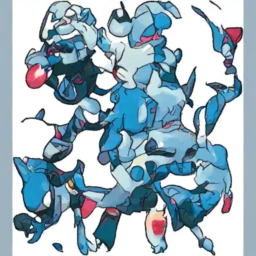

In [26]:
import torch
import matplotlib.pyplot as plt
import torchvision.utils as vutils
import torchvision.transforms as transforms
from elucidated_diffusion.image_helpers import pil_to_data_url, html_for_images
def generate_images(model_edm, num_steps=15, batch_size=20, img_shape = (3,64,64)):
    print("in genimgs ",img_shape)
    to_pil = transforms.ToPILImage()
    with torch.no_grad():
        samples = edm_ancestral_sampling_for_diffusion(model_edm, num_steps=num_steps, batch_size=batch_size, img_shape=img_shape).cpu()
        samples = (samples + 1) / 2  # scale from [-1,1] to [0,1]
        samples = samples.clamp(0, 1)
        pil_images = [to_pil(img) for img in samples]
    return pil_images

def sample_html(model, batch_size=12, img_shape=(3,64,64), num_steps=36, title="EDM Samples",min_height=128):
    print("in sample_haml ",img_shape)
    imgs = generate_images(model_edm=model, batch_size=batch_size, img_shape=img_shape, num_steps=16)
    h = html_for_images(imgs, title=title, min_height=min_height)
    return h

cp = '../checkpoints/good/SkipAttentionUNet_2025-12-03_19-26-19_pokemon_efficient.pth'
lm = load_checkpoint(m,None,cp)
h = sample_html(m,title=f"Samples from {cp}",min_height=128, batch_size=1, img_shape=(3,128*2,128*2))
import IPython.display as ipd
ipd.display(ipd.HTML(h))

in sample_haml  (3, 512, 512)
in genimgs  (3, 512, 512)
in edm_ancestral_sampling_for_diffusion shape is  (3, 512, 512)
in uified_edm_sampleing shape is  (3, 512, 512)



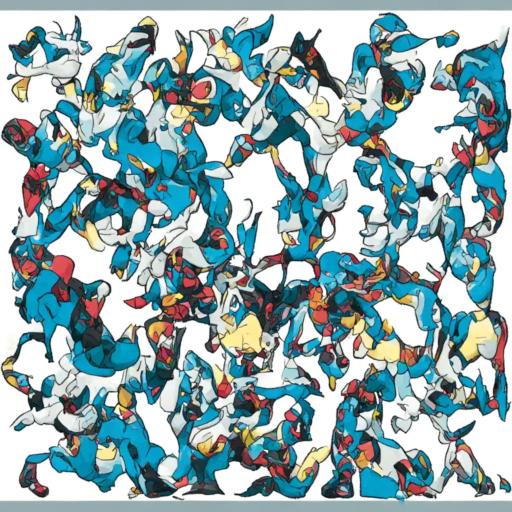

CPU times: user 16min 35s, sys: 13min 52s, total: 30min 28s
Wall time: 5min 20s


In [29]:
%%time
# Takes like 20GB of RAM and 15 minutes
h = sample_html(m,title=f"Samples from {cp}",min_height=128, batch_size=1, img_shape=(3,128*4,128*4))
import IPython.display as ipd
ipd.display(ipd.HTML(h))

in sample_haml  (3, 128, 128)
in genimgs  (3, 128, 128)
in edm_ancestral_sampling_for_diffusion shape is  (3, 128, 128)
in uified_edm_sampleing shape is  (3, 128, 128)



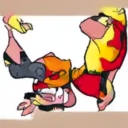
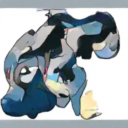
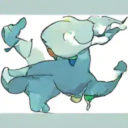
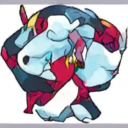

CPU times: user 1min 29s, sys: 18.7 s, total: 1min 48s
Wall time: 14.8 s


In [38]:
%%time
# Takes like 20GB of RAM and 15 minutes
h = sample_html(m,title=f"Samples from {cp}",min_height=128, batch_size=4, img_shape=(3,128,128))
import IPython.display as ipd
ipd.display(ipd.HTML(h))

in sample_haml  (3, 128, 128)
in genimgs  (3, 128, 128)
in edm_ancestral_sampling_for_diffusion shape is  (3, 128, 128)
in uified_edm_sampleing shape is  (3, 128, 128)



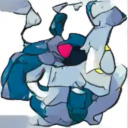
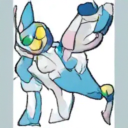
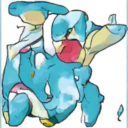
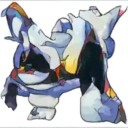
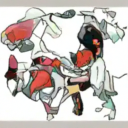
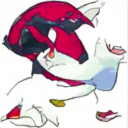
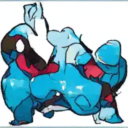
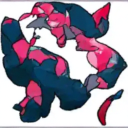

CPU times: user 2min 58s, sys: 57.1 s, total: 3min 55s
Wall time: 34.5 s


In [39]:
%%time
# Takes like 20GB of RAM and 15 minutes
h = sample_html(m,title=f"Samples from {cp}",min_height=128, batch_size=8, img_shape=(3,128,128))
import IPython.display as ipd
ipd.display(ipd.HTML(h))

In [7]:
def generate_html_examples(cp="checkpoints/UNet128_2025-09-12_19-47-15_dragon.pth",batch_size=12, img_shape=(3,128,128)):
    with torch.no_grad():
        model_edm = UNet128(use_attention=True).to(device)
        optimizer_edm = None
        load_checkpoint(model_edm, optimizer_edm, cp)
        h = sample_html(model_edm,title=f"Samples from {cp}",min_height=1024, batch_size=batch_size, img_shape=img_shape)
        ipd.display(ipd.HTML(h))
        model_edm.to('cpu')


def demo_semantic_coordinator():
    img_size=128
    model_edm = create_semantic_coordinator(
        img_size=img_size,
        cnn_layers=3,        vit_layers=4,        cnn_resolution=16,        vit_resolution=16,
    ).to(device)
    cp = 'checkpoints/UnifiedSemanticCoordinatorUNet_2025-12-01_09-25-10_pokemon_efficient.pth'
    optimizer_edm = None
    load_checkpoint(model_edm, optimizer_edm, cp)
    h = sample_html(model_edm,  img_shape=(3,img_size,img_size), 
                                title=f"EDM of {model_edm.__class__.__name__}"
                                )
    ipd.display(ipd.HTML(h))
    model_edm.to('cpu')
demo_semantic_coordinator()



generate
        

TypeError: SkipAttentionUNet.forward() missing 2 required positional arguments: 'x' and 't'

In [12]:
m =  create_semantic_coordinator(config='balanced', img_size=128)
show_model_info(m)

Channel schedule: [64, 64, 256, 512]
Total parameters: 18,804,355
Trainable parameters: 18,804,355 (100.00%)

Parameter breakdown by top-level module:
cnn_decoder                         total:   11,744,707   trainable:   11,744,707   trainable%: 100.00
cnn_encoder                         total:    4,654,400   trainable:    4,654,400   trainable%: 100.00
vit_blocks                          total:    2,125,824   trainable:    2,125,824   trainable%: 100.00
from_vit                            total:      131,584   trainable:      131,584   trainable%: 100.00
to_vit                              total:      131,328   trainable:      131,328   trainable%: 100.00
time_mlp                            total:       16,512   trainable:       16,512   trainable%: 100.00

Top 10 largest parameter tensors:
cnn_decoder.blocks.0.conv1.weight                            shape: (512, 1024, 3, 3) params:    4,718,592  train
cnn_encoder.blocks.3.conv2.weight                            shape: (512, 512, 3, 

In [9]:
m = create_gradual_transition_unet("balanced").to('cpu')
show_model_info(m)


Total parameters: 10,407,283
Trainable parameters: 10,407,283 (100.00%)

Parameter breakdown by top-level module:
enc3                                total:    2,307,840   trainable:    2,307,840   trainable%: 100.00
dec4                                total:    1,490,240   trainable:    1,490,240   trainable%: 100.00
dec3                                total:    1,486,720   trainable:    1,486,720   trainable%: 100.00
enc4                                total:    1,285,120   trainable:    1,285,120   trainable%: 100.00
bottleneck1                         total:    1,285,120   trainable:    1,285,120   trainable%: 100.00
bottleneck2                         total:    1,285,120   trainable:    1,285,120   trainable%: 100.00
enc2                                total:      590,720   trainable:      590,720   trainable%: 100.00
dec2                                total:      378,560   trainable:      378,560   trainable%: 100.00
dec1                                total:      198,720   trai

In [13]:
m =  create_vit_enhanced_unet("balanced")
show_model_info(m)

Total parameters: 9,695,747
Trainable parameters: 9,695,747 (100.00%)

Parameter breakdown by top-level module:
vit_blocks                          total:    3,159,040   trainable:    3,159,040   trainable%: 100.00
up_block3                           total:    1,934,336   trainable:    1,934,336   trainable%: 100.00
down3                               total:    1,213,184   trainable:    1,213,184   trainable%: 100.00
down2                               total:      951,296   trainable:      951,296   trainable%: 100.00
up_block2                           total:      655,872   trainable:      655,872   trainable%: 100.00
mha_16                              total:      263,680   trainable:      263,680   trainable%: 100.00
mha_8                               total:      263,680   trainable:      263,680   trainable%: 100.00
up3                                 total:      262,400   trainable:      262,400   trainable%: 100.00
down1                               total:      246,272   traina

In [ ]:

#model_edm = SkipAttentionUNet().to(device) # Train one of these longer -- they're awesome at pokemon # 2025-12-02
#model_edm = MultiScaleSharedViT().to(device)
model_edm = SemanticCascadeViT().to(device)